> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 24. Interpretability and Deployment

*Scope:* Explaining what a fitted model actually learned, then getting it out of the notebook and keeping it honest over time.

Chapter 23 ended with a single picklable object that turns a raw row into a prediction. Two questions
remain, and they are the ones that decide whether the work was worth doing.

**What did it learn?** Not what it predicts — what it *learned*, which is the question asked by a regulator,
a domain expert who thinks the model is wrong, and the customer who was declined.

**Will it still be right next month?** A fitted model is a photograph of a distribution. The distribution
moves.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 80
print("ready")

ready


In [2]:
customers = pd.read_csv("data/customers.csv").drop_duplicates().reset_index(drop=True)
customers["total_charges"] = pd.to_numeric(customers["total_charges"], errors="coerce")

NUMERIC = ["tenure_months", "monthly_charges", "total_charges", "support_tickets",
           "last_login_days", "satisfaction_score", "age"]
CATEGORICAL = ["gender", "plan", "city"]

data = customers[NUMERIC + CATEGORICAL].copy()
# Cast the numeric block to float: PartialDependenceDisplay (24.4) refuses integer
# columns outright, because sweeping one implies fractional values it cannot represent.
data[NUMERIC] = data[NUMERIC].astype(float)
target = customers["churned"].to_numpy()

X_tr, X_te, y_tr, y_te = train_test_split(data, target, test_size=0.25,
                                          stratify=target, random_state=RANDOM_STATE)
print(f"train {X_tr.shape}, test {X_te.shape}, churn rate {target.mean():.2%}")
print(f"numeric dtypes: {set(data[NUMERIC].dtypes.astype(str))}")

train (750, 10), test (250, 10), churn rate 14.10%
numeric dtypes: {'float64'}


In [3]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("encode", OneHotEncoder(handle_unknown="ignore",
                                               sparse_output=False))]), CATEGORICAL),
])

forest = Pipeline([("prep", preprocess),
                   ("clf", RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                                  class_weight="balanced",
                                                  random_state=RANDOM_STATE))]).fit(X_tr, y_tr)

FEATURES = list(forest.named_steps["prep"].get_feature_names_out())
print(f"{len(FEATURES)} encoded features")
print(f"test ROC-AUC: {roc_auc_score(y_te, forest.predict_proba(X_te)[:, 1]):.4f}")

24 encoded features
test ROC-AUC: 0.8019


### 24.1 Why Interpretability Matters

"Interpretability" covers several different requirements that happen to share a word, and conflating them
leads to producing the wrong artefact.

| Question | Wants | Tool |
|---|---|---|
| What does the model rely on, overall? | **Global** explanation | Coefficients (24.2), permutation importance (24.3) |
| What shape is the relationship? | Global, per feature | Partial dependence (24.4) |
| Why *this* prediction? | **Local** explanation | SHAP (24.5), LIME (24.6) |
| Is the model using something it shouldn't? | An audit | 24.3 plus domain review (22.9.1) |
| Is it fair across groups? | A fairness analysis | 24.7 |
| Can I predict how it will behave? | A **simple** model | 24.2 |

The distinction that matters most is **global versus local**. A global explanation describes the model; a
local one describes one decision. They routinely disagree, and neither is wrong when they do.

There is also a trade-off worth measuring rather than asserting.

In [4]:
simple = Pipeline([("prep", preprocess),
                   ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                              random_state=RANDOM_STATE))]).fit(X_tr, y_tr)
stump = Pipeline([("prep", preprocess),
                  ("clf", DecisionTreeClassifier(max_depth=3, class_weight="balanced",
                                                 random_state=RANDOM_STATE))]).fit(X_tr, y_tr)
boosted = Pipeline([("prep", preprocess),
                    ("clf", HistGradientBoostingClassifier(
                        random_state=RANDOM_STATE))]).fit(X_tr, y_tr)

rows = []
for name, m, kind in (("depth-3 tree", stump, "readable end to end"),
                      ("logistic regression", simple, "one weight per feature"),
                      ("random forest", forest, "200 trees - not readable"),
                      ("hist gradient boosting", boosted, "not readable")):
    rows.append({"model": name,
                 "test ROC-AUC": roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]),
                 "interpretability": kind})

print(pd.DataFrame(rows).round(4).to_string(index=False))

                 model  test ROC-AUC         interpretability
          depth-3 tree        0.8216      readable end to end
   logistic regression        0.7894   one weight per feature
         random forest        0.8019 200 trees - not readable
hist gradient boosting        0.7281             not readable


**On this problem there is no trade-off at all: the depth-3 tree wins.** It scores above the 200-tree
forest and well above gradient boosting, and it fits on one screen. The received framing —
interpretability is bought with accuracy — simply does not hold here.

This is not a trick, and it is not rare. 1000 rows, ten features and a 14% positive rate is a small
problem, and small problems are where a high-variance model has the least to offer and the most to lose
(9.2). Chapter 19 found the same thing from the other direction, with gradient boosting placing sixth on a
similar churn dataset.

The lesson is not "simple models are better". It is that **the trade-off has to be measured on your
problem before it is conceded.** Where the gap is genuinely large, explaining a complex model is worth the
effort; where the table looks like this one, choosing the forest and then spending a chapter explaining it
is a decision that needs saying out loud.

The rest of this chapter explains the forest anyway — because the techniques are what transfer, and
because the situation where you *have* to explain a complex model is common enough to be worth knowing
how to handle.

### 24.2 Intrinsically Interpretable Models

Some models are explanations. A depth-3 tree can be printed and read; a linear model is a list of weights.
No post-hoc method is as trustworthy, because there is nothing to approximate.

In [5]:
tree = stump.named_steps["clf"]
print(export_text(tree, feature_names=FEATURES, max_depth=3, decimals=2))

|--- num__tenure_months <= -0.28
|   |--- num__support_tickets <= 0.22
|   |   |--- num__monthly_charges <= -0.67
|   |   |   |--- class: 0
|   |   |--- num__monthly_charges >  -0.67
|   |   |   |--- class: 1
|   |--- num__support_tickets >  0.22
|   |   |--- num__total_charges <= -0.22
|   |   |   |--- class: 1
|   |   |--- num__total_charges >  -0.22
|   |   |   |--- class: 0
|--- num__tenure_months >  -0.28
|   |--- num__satisfaction_score <= 0.13
|   |   |--- num__tenure_months <= 0.59
|   |   |   |--- class: 1
|   |   |--- num__tenure_months >  0.59
|   |   |   |--- class: 0
|   |--- num__satisfaction_score >  0.13
|   |   |--- cat__city_Delhi <= 0.50
|   |   |   |--- class: 0
|   |   |--- cat__city_Delhi >  0.50
|   |   |   |--- class: 1



That output *is* the model — every prediction it will ever make is traceable through it. Compare with a
forest, where the same information exists 200 times over and cannot be read.

For logistic regression the coefficients are log-odds (13.7), and exponentiating turns them into odds
ratios, which is the form a domain expert can actually check.

In [6]:
coefs = pd.Series(simple.named_steps["clf"].coef_[0], index=FEATURES)
summary = pd.DataFrame({"coefficient": coefs, "odds ratio": np.exp(coefs)})
summary = summary.reindex(coefs.abs().sort_values(ascending=False).index)

print(summary.head(8).round(3).to_string())
print("\nfeatures are standardised, so each coefficient is 'per one standard deviation'")

                         coefficient  odds ratio
num__tenure_months            -0.984       0.374
cat__city_Delhi                0.742       2.100
cat__gender_female            -0.616       0.540
num__support_tickets           0.522       1.686
num__satisfaction_score       -0.492       0.612
cat__gender_Female             0.438       1.549
cat__city_Jaipur              -0.401       0.670
cat__city_Pune                -0.350       0.705

features are standardised, so each coefficient is 'per one standard deviation'


**Common mistake — reading coefficient magnitudes as importance without checking the scaling.** An
unstandardised coefficient is per *unit*, so a feature measured in rupees and one measured in years are
not comparable at all. The scaling in the pipeline is what makes the comparison above legitimate.

In [7]:
# The same model with no scaler: identical predictions, meaningless coefficient ranking.
unscaled = Pipeline([
    ("prep", ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), NUMERIC),
        ("cat", Pipeline([("i", SimpleImputer(strategy="most_frequent")),
                          ("e", OneHotEncoder(handle_unknown="ignore",
                                              sparse_output=False))]), CATEGORICAL)]),),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced",
                               random_state=RANDOM_STATE)),
]).fit(X_tr, y_tr)

raw_coefs = pd.Series(unscaled.named_steps["clf"].coef_[0],
                      index=unscaled.named_steps["prep"].get_feature_names_out())

print("largest |coefficient| without scaling:")
print(raw_coefs.reindex(raw_coefs.abs().sort_values(ascending=False).index)
      .head(4).round(4).to_string())
print("\nlargest |coefficient| with scaling:")
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(4).round(4).to_string())

largest |coefficient| without scaling:
cat__city_Delhi         0.7512
cat__gender_female     -0.6246
num__support_tickets    0.4682
cat__gender_Female      0.4391

largest |coefficient| with scaling:
num__tenure_months     -0.9841
cat__city_Delhi         0.7421
cat__gender_female     -0.6160
num__support_tickets    0.5221


D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The two rankings disagree, and only the scaled one answers "which feature matters most". The unscaled
coefficients answer a different question — "what happens per unit" — which is also useful, and is not
importance.

### 24.3 Permutation Importance

18.8.1 introduced this; here it is the primary global tool for a model that has no coefficients.

The idea is model-agnostic and requires no retraining: **shuffle one feature's column and measure how much
the score drops.** If the model depended on that feature, breaking its relationship with the target hurts.

$$\text{importance}_j = s - \frac{1}{K}\sum_{k=1}^{K} s_{k,j}$$

where $s$ is the score on intact data and $s_{k,j}$ the score with feature $j$ shuffled.

| | Impurity importance (17.8) | Permutation importance |
|---|---|---|
| Computed from | The fitted trees | **Any** model, by scoring |
| Measures | Reduction in training impurity | Drop in the metric you chose |
| Biased towards | High-cardinality features | — |
| Uses | Training data | **Should use held-out data** |
| Cost | Free | One re-score per feature per repeat |
| Correlated features | Splits the credit | **Both look unimportant** |

The "uses held-out data" row is the one that changes the answer.

In [8]:
result_train = permutation_importance(forest, X_tr, y_tr, n_repeats=8,
                                      scoring="roc_auc", random_state=RANDOM_STATE)
result_test = permutation_importance(forest, X_te, y_te, n_repeats=8,
                                     scoring="roc_auc", random_state=RANDOM_STATE)

comparison = pd.DataFrame({
    "on train": result_train.importances_mean,
    "on test": result_test.importances_mean,
}, index=data.columns).sort_values("on test", ascending=False)

print(comparison.round(4).to_string())

                    on train  on test
tenure_months         0.0749   0.0967
total_charges         0.0257   0.0351
support_tickets       0.0447   0.0243
age                   0.0245   0.0031
plan                  0.0199  -0.0022
monthly_charges       0.0272  -0.0028
city                  0.0190  -0.0037
last_login_days       0.0217  -0.0039
gender                0.0189  -0.0048
satisfaction_score    0.0493  -0.0120


Computed on the training set, permutation importance measures what the model *used* — including whatever it
memorised. On held-out data it measures what the model uses **to generalise**, which is almost always the
question. Report the test-set version.

Notice what the two columns do to `satisfaction_score`: comfortably positive on training data, and
**negative on test**. A negative permutation importance means shuffling the column *improved* the held-out
score — the model's use of that feature does not generalise, and on this test set it actively hurts.

Several features land slightly below zero here, and most of those are noise around a true importance of
roughly zero rather than a real effect. The reading is the same either way: **those features are not
earning their place**, and the training-set column would have hidden that completely.

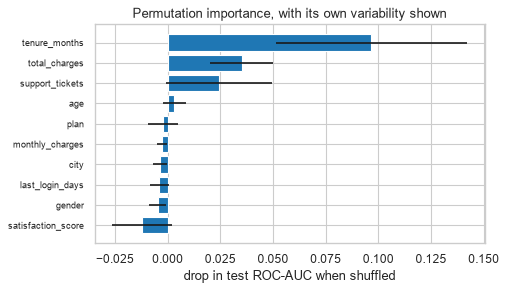

In [9]:
order = comparison.index[::-1]
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.barh(range(len(order)),
        [result_test.importances_mean[list(data.columns).index(f)] for f in order],
        xerr=[result_test.importances_std[list(data.columns).index(f)] for f in order],
        color="tab:blue")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel("drop in test ROC-AUC when shuffled")
ax.set_title("Permutation importance, with its own variability shown")
fig.tight_layout()
plt.show()

**Common mistake — trusting permutation importance under correlated features.** If two features carry the
same information, shuffling either one leaves the model able to recover the signal from the other, so
**both look unimportant**. 18.8.1 measured this; here it is with a duplicated column.

In [10]:
X_tr_dup = X_tr.assign(tenure_copy=X_tr["tenure_months"])
X_te_dup = X_te.assign(tenure_copy=X_te["tenure_months"])

dup_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("i", SimpleImputer(strategy="median")),
                          ("s", StandardScaler())]), NUMERIC + ["tenure_copy"]),
        ("cat", Pipeline([("i", SimpleImputer(strategy="most_frequent")),
                          ("e", OneHotEncoder(handle_unknown="ignore",
                                              sparse_output=False))]), CATEGORICAL)])),
    ("clf", RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                   class_weight="balanced", random_state=RANDOM_STATE)),
]).fit(X_tr_dup, y_tr)

dup_result = permutation_importance(dup_pipe, X_te_dup, y_te, n_repeats=8,
                                    scoring="roc_auc", random_state=RANDOM_STATE)
dup_imp = pd.Series(dup_result.importances_mean, index=X_te_dup.columns)

print(f"tenure_months, alone      : {comparison.loc['tenure_months', 'on test']:.4f}")
print(f"tenure_months, duplicated : {dup_imp['tenure_months']:.4f}")
print(f"tenure_copy               : {dup_imp['tenure_copy']:.4f}")
print(f"\nsum of the two           : {dup_imp['tenure_months'] + dup_imp['tenure_copy']:.4f}")

tenure_months, alone      : 0.0967
tenure_months, duplicated : 0.0281
tenure_copy               : 0.0427

sum of the two           : 0.0708


**Permutation importance answers "what would break if I lost this column", not "how much does this
information matter".** Under duplication those are different questions with different answers, and the
first one is the honest reading of the number.

### 24.4 Partial Dependence and ICE

Importance says *how much* a feature matters. It says nothing about *which direction* or *what shape* —
and for a non-linear model the shape is the interesting part.

A **partial dependence plot** averages the model's prediction as one feature is swept across its range,
holding the others at their observed values:

$$\text{PD}_j(v) = \frac{1}{n} \sum_{i=1}^{n} \hat{f}\!\left(x_i \text{ with } x_{ij} = v\right)$$

**ICE** (individual conditional expectation) draws one line per row instead of the average — which reveals
whether the average is hiding disagreement between subgroups.

plotting partial dependence for: ['tenure_months', 'total_charges', 'support_tickets']


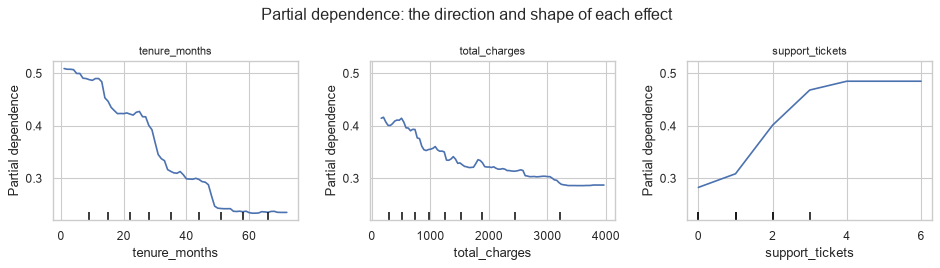

In [11]:
top_features = list(comparison.index[:3])
print(f"plotting partial dependence for: {top_features}")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
PartialDependenceDisplay.from_estimator(
    forest, X_tr, features=top_features, ax=ax, kind="average",
    random_state=RANDOM_STATE)
for a in ax:
    a.set_title(a.get_xlabel(), fontsize=10)
fig.suptitle("Partial dependence: the direction and shape of each effect")
fig.tight_layout()
plt.show()

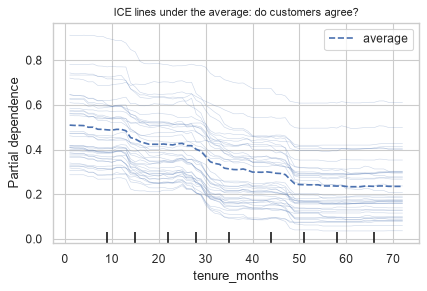

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 3.8))
PartialDependenceDisplay.from_estimator(
    forest, X_tr, features=[top_features[0]], ax=ax, kind="both",
    subsample=40, random_state=RANDOM_STATE)
ax.set_title(f"ICE lines under the average: do customers agree?", fontsize=10)
fig.tight_layout()
plt.show()

**Common mistake — reading a PDP as causal.** The plot says *"if the model were shown a customer with this
value, it would predict this"*. It does not say that changing the value would change the outcome. The model
learned an association (22.7.1's calendar question again); a PDP visualises the association.

**The second problem is extrapolation.** Partial dependence evaluates the model at feature combinations
that may not exist — sweeping `tenure_months` to 60 while holding `total_charges` at a 3-month value asks
the model about a customer who cannot exist.

In [13]:
# How correlated are the features being swept independently?
corr = X_tr[NUMERIC].corr().abs().to_numpy()

pairs = sorted(
    ((corr[i, j], NUMERIC[i], NUMERIC[j])
     for i in range(len(NUMERIC)) for j in range(i + 1, len(NUMERIC))),
    reverse=True)

print("most correlated numeric pairs - PDPs over these are extrapolating:")
for value, a, b in pairs[:3]:
    print(f"  {a:<20} / {b:<20} r = {value:.3f}")

most correlated numeric pairs - PDPs over these are extrapolating:
  tenure_months        / total_charges        r = 0.762
  support_tickets      / satisfaction_score   r = 0.699
  monthly_charges      / total_charges        r = 0.606


A correlation of that size means the PDP for either feature is being evaluated on combinations the data
never contains. **Accumulated local effects (ALE)** solve this by averaging over local neighbourhoods
instead of the full marginal, and are the better choice when features are strongly correlated.

### 24.5 SHAP

Everything so far explains the model. SHAP explains **one prediction**, and does it with a property the
others lack: the contributions add up.

$$\hat{f}(x) = \phi_0 + \sum_{j=1}^{p} \phi_j$$

$\phi_0$ is the average prediction and $\phi_j$ is feature $j$'s contribution for *this* row. The values
come from cooperative game theory — the Shapley value, which is the unique attribution satisfying
efficiency, symmetry, dummy and additivity.

| | SHAP | LIME (24.6) |
|---|---|---|
| Basis | Shapley values — axiomatic | A local surrogate model |
| Adds up to the prediction | **Yes**, exactly | No |
| Deterministic | Yes for `TreeExplainer` | **No** — depends on sampling |
| Global view | Yes, by aggregating local values | Not really |
| Cost | Fast for trees, slow otherwise | Fast |

In [14]:
import shap

# TreeExplainer is exact and fast for tree ensembles. Explain the ENCODED features,
# so the pipeline's transform has to be applied first.
X_te_encoded = pd.DataFrame(forest.named_steps["prep"].transform(X_te), columns=FEATURES)
X_tr_encoded = pd.DataFrame(forest.named_steps["prep"].transform(X_tr), columns=FEATURES)

explainer = shap.TreeExplainer(forest.named_steps["clf"])
shap_values = explainer.shap_values(X_te_encoded, check_additivity=False)

# For a binary classifier sklearn returns (n, p, 2); take the positive class.
positive = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values
print(f"SHAP values shape: {positive.shape}  (rows x features)")

SHAP values shape: (250, 24)  (rows x features)


In [15]:
# The additivity property, checked rather than asserted.
base_value = (explainer.expected_value[1] if np.ndim(explainer.expected_value)
              else explainer.expected_value)
reconstructed = base_value + positive.sum(axis=1)
actual = forest.named_steps["clf"].predict_proba(X_te_encoded)[:, 1]

print(f"base value (mean prediction) : {base_value:.4f}")
print(f"max |reconstruction error|   : {np.abs(reconstructed - actual).max():.2e}")
print(f"additivity holds             : {np.allclose(reconstructed, actual, atol=1e-6)}")

base value (mean prediction) : 0.5005
max |reconstruction error|   : 1.50e-15
additivity holds             : True


D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


That is the property that makes SHAP usable in a conversation: the explanation of a prediction sums to the
prediction, so "we started here, and these five things moved you to there" is arithmetically true rather
than a rough indication. The reconstruction error above is at the limit of floating-point precision.

**The base value is 0.50, not the 14% churn rate**, and the reason is worth pinning down: this forest was
fitted with `class_weight="balanced"` (22.4), so it behaves as though the classes were equally common and
its average output is near 0.5. The base value is *the model's* mean prediction, not the population's
churn rate. Quoting it to a stakeholder as "the average customer's risk" would be wrong — it is the
average customer's risk **according to a model that was told the classes are balanced**.

**The global view comes free**, by averaging the absolute local values.

In [16]:
global_shap = pd.Series(np.abs(positive).mean(axis=0), index=FEATURES)
top = global_shap.sort_values(ascending=False).head(8)

print("mean |SHAP| - global importance, derived from local explanations:")
print(top.round(4).to_string())

mean |SHAP| - global importance, derived from local explanations:
num__tenure_months         0.0995
num__support_tickets       0.0718
num__satisfaction_score    0.0671
num__total_charges         0.0479
num__monthly_charges       0.0213
num__age                   0.0175
num__last_login_days       0.0149
cat__plan_Basic            0.0136


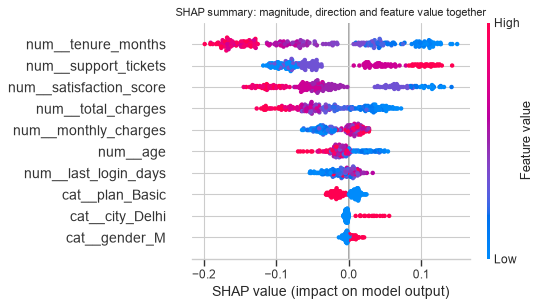

In [17]:
fig = plt.figure(figsize=(7, 4))
shap.summary_plot(positive, X_te_encoded, max_display=10, show=False, plot_size=None)
plt.title("SHAP summary: magnitude, direction and feature value together", fontsize=10)
plt.tight_layout()
plt.show()

The summary plot carries more than a bar chart: each dot is one customer, its horizontal position is that
customer's SHAP value, and its colour is the feature's value. A band that runs from blue on the left to red
on the right means high values of that feature push the prediction up — direction and magnitude in one
figure.

**Now a single prediction**, which is what a customer-facing explanation actually needs.

In [18]:
idx = int(np.argmax(actual))                            # the highest-risk customer in the test set

contribution = pd.Series(positive[idx], index=FEATURES)
top_drivers = contribution.reindex(contribution.abs().sort_values(ascending=False).index).head(6)

print(f"customer at test index {idx}: predicted churn probability {actual[idx]:.3f}")
print(f"base rate: {base_value:.3f}\n")
print("the six features that moved this prediction most:")
for feature, value in top_drivers.items():
    arrow = "up  " if value > 0 else "down"
    print(f"  {feature:<28} {arrow} {value:+.4f}")
print(f"\nsum of ALL contributions: {contribution.sum():+.4f}"
      f"  ->  {base_value:.3f} + {contribution.sum():.3f} = {actual[idx]:.3f}")

customer at test index 11: predicted churn probability 0.898
base rate: 0.500

the six features that moved this prediction most:
  num__satisfaction_score      up   +0.1174
  num__support_tickets         up   +0.1104
  num__tenure_months           up   +0.1072
  num__total_charges           up   +0.0676
  num__monthly_charges         down -0.0207
  cat__gender_F                up   +0.0125

sum of ALL contributions: +0.3976  ->  0.500 + 0.398 = 0.898


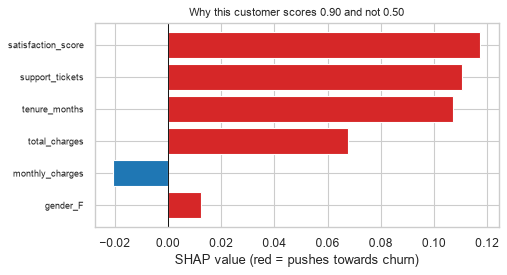

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ordered = top_drivers[::-1]
ax.barh(range(len(ordered)), ordered.values,
        color=["tab:red" if v > 0 else "tab:blue" for v in ordered.values])
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels([f.replace("num__", "").replace("cat__", "") for f in ordered.index],
                   fontsize=8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("SHAP value (red = pushes towards churn)")
ax.set_title(f"Why this customer scores {actual[idx]:.2f} and not {base_value:.2f}", fontsize=10)
fig.tight_layout()
plt.show()

**Common mistake — treating SHAP values as instructions.** A negative SHAP value for
`satisfaction_score` does not mean raising that customer's satisfaction by a point will lower their churn
probability by that amount. SHAP attributes the model's output among the features it was given; it is an
explanation of a prediction, not an estimate of an intervention's effect. That is a causal question and
needs a causal method.

### 24.6 LIME

LIME takes a different route to the same goal: perturb the row, see how the model's prediction responds,
and **fit a simple model to those local responses**. The simple model's coefficients are the explanation.

Its strength is that it is genuinely model-agnostic — it needs only `predict_proba`. Its weakness follows
from the method: the explanation depends on the random perturbations, so **it is not stable**.

In [20]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    X_tr_encoded.to_numpy(), feature_names=FEATURES,
    class_names=["stays", "churns"], mode="classification",
    discretize_continuous=True, random_state=RANDOM_STATE)

explanation = lime_explainer.explain_instance(
    X_te_encoded.iloc[idx].to_numpy(),
    forest.named_steps["clf"].predict_proba, num_features=6)

print(f"LIME explanation for the same customer (index {idx}):\n")
for feature, weight in explanation.as_list():
    print(f"  {feature:<44} {weight:+.4f}")

LIME explanation for the same customer (index 11):

  num__tenure_months <= -0.89                  +0.1742
  num__satisfaction_score <= -0.80             +0.1508
  num__support_tickets > 0.66                  +0.1315
  num__total_charges <= -0.79                  +0.0770
  num__monthly_charges <= -0.81                -0.0395
  0.00 < cat__plan_Basic <= 1.00               -0.0356


**The instability, measured.** Running LIME several times on the *same row* with the *same model* gives
different explanations, because each run draws new perturbations. The question is how much.

In [21]:
import re


def lime_feature(condition):
    """Pull the feature name out of a LIME condition like 'num__age <= -0.89'."""
    names = [f for f in FEATURES if f in condition]
    return max(names, key=len) if names else condition


runs, weights = [], {}
for seed in range(5):
    ex = LimeTabularExplainer(
        X_tr_encoded.to_numpy(), feature_names=FEATURES, mode="classification",
        discretize_continuous=True, random_state=seed).explain_instance(
        X_te_encoded.iloc[idx].to_numpy(),
        forest.named_steps["clf"].predict_proba, num_features=5)
    picked = [lime_feature(c) for c, _ in ex.as_list()]
    runs.append(picked)
    for (condition, w), name in zip(ex.as_list(), picked):
        weights.setdefault(name, []).append(w)

print("top-5 features chosen, per run:")
for i, r in enumerate(runs):
    print(f"  run {i}: {[f.replace('num__', '').replace('cat__', '') for f in r]}")

always = set.intersection(*(set(r) for r in runs))
ever = set.union(*(set(r) for r in runs))
print(f"\nchosen in every run: {len(always)};  in at least one: {len(ever)}")

top-5 features chosen, per run:
  run 0: ['tenure_months', 'satisfaction_score', 'support_tickets', 'total_charges', 'plan_Basic']
  run 1: ['tenure_months', 'satisfaction_score', 'support_tickets', 'total_charges', 'plan_Basic']
  run 2: ['tenure_months', 'satisfaction_score', 'support_tickets', 'total_charges', 'monthly_charges']
  run 3: ['tenure_months', 'satisfaction_score', 'support_tickets', 'total_charges', 'plan_Basic']
  run 4: ['tenure_months', 'satisfaction_score', 'support_tickets', 'total_charges', 'monthly_charges']

chosen in every run: 4;  in at least one: 6


In [22]:
# The ranking is fairly stable here. The WEIGHTS are where the variation shows.
print(f"{'feature':>28}{'runs':>6}{'mean w':>10}{'min':>10}{'max':>10}{'spread':>9}")
for name, ws in sorted(weights.items(), key=lambda kv: -abs(np.mean(kv[1]))):
    clean = name.replace("num__", "").replace("cat__", "")
    print(f"{clean:>28}{len(ws):>6}{np.mean(ws):>10.4f}{min(ws):>10.4f}"
          f"{max(ws):>10.4f}{max(ws) - min(ws):>9.4f}")

                     feature  runs    mean w       min       max   spread
               tenure_months     5    0.1793    0.1737    0.1855   0.0118
          satisfaction_score     5    0.1489    0.1470    0.1509   0.0040
             support_tickets     5    0.1274    0.1232    0.1309   0.0077
               total_charges     5    0.0783    0.0734    0.0798   0.0064
             monthly_charges     2   -0.0412   -0.0431   -0.0393   0.0038
                  plan_Basic     3   -0.0389   -0.0412   -0.0368   0.0043


In [23]:
# SHAP, by contrast, is deterministic for a tree model.
again = shap.TreeExplainer(forest.named_steps["clf"]).shap_values(
    X_te_encoded.iloc[[idx]], check_additivity=False)
again_pos = again[:, :, 1] if again.ndim == 3 else again

print(f"SHAP recomputed - identical: {np.allclose(again_pos[0], positive[idx])}")

SHAP recomputed - identical: True


**In practice** — for tree models, which is most tabular work, `shap.TreeExplainer` is exact, fast and
deterministic, and there is little reason to prefer LIME. LIME's place is explaining a model you cannot
open at all — a remote API, or something with no SHAP explainer — where "only needs `predict_proba`" is
the deciding constraint. When it is used, report explanations averaged over several seeds, not one run.

### 24.7 Fairness and Bias

A model trained on historical data reproduces the patterns in that data, including the ones nobody wants
reproduced. This section is a short, factual treatment of the measurement problem; the policy questions
are outside the scope of this material.

The first fact is that **the common fairness criteria are mutually incompatible** — except in degenerate
cases, you cannot satisfy them all, so choosing one is a decision that cannot be delegated to a metric.

| Criterion | Requires | In words |
|---|---|---|
| **Demographic parity** | $P(\hat{y}{=}1 \mid A{=}a)$ equal | The same selection rate per group |
| **Equal opportunity** | $P(\hat{y}{=}1 \mid y{=}1, A{=}a)$ equal | The same **recall** per group |
| **Equalised odds** | Equal TPR **and** FPR | The same error profile per group |
| **Predictive parity** | $P(y{=}1 \mid \hat{y}{=}1, A{=}a)$ equal | The same **precision** per group |
| **Calibration by group** | $P(y{=}1 \mid \hat{p}, A{=}a)$ equal | A 0.7 means 0.7 in every group |

Removing the attribute does not remove the problem, because other features carry it.

In [24]:
# Is the sensitive attribute recoverable from the other features? If so, dropping it does nothing.
sensitive = customers.loc[data.index, "gender"].str.strip().str.lower().replace(
    {"male": "m", "female": "f"})
has_gender = sensitive.isin(["m", "f"])

probe_X = data.loc[has_gender, NUMERIC].fillna(data[NUMERIC].median())
probe_y = (sensitive[has_gender] == "f").astype(int)

probe_auc = cross_val_score(
    Pipeline([("s", StandardScaler()), ("c", LogisticRegression(max_iter=2000,
                                                                random_state=RANDOM_STATE))]),
    probe_X, probe_y, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc").mean()

print(f"predicting gender from the NON-gender features: ROC-AUC {probe_auc:.4f}")
print(f"chance: 0.5000")
print("->", "the attribute leaks into the other features" if probe_auc > 0.6
      else "not recoverable here - dropping the column genuinely removes it")

predicting gender from the NON-gender features: ROC-AUC 0.4809
chance: 0.5000
-> not recoverable here - dropping the column genuinely removes it


**This is the "fairness through unawareness" fallacy, tested rather than asserted.** Run the probe before
concluding anything: if the attribute is recoverable, removing the column changes nothing except your
ability to measure the disparity. If it is *not* recoverable — as the number above indicates for this
dataset — then dropping it does work, and that is worth knowing too.

Either way, the sensitive attribute is needed **to audit** the model, even if it is not used to train it.

In [25]:
def group_metrics(y_true, y_pred, y_proba, groups):
    rows = []
    # 46 customers have no recorded gender; they are excluded from the group
    # comparison rather than pooled into a third bucket that means "unknown".
    present = sorted(v for v in pd.unique(groups) if isinstance(v, str))
    for g in present:
        m = groups == g
        if m.sum() < 20 or y_true[m].sum() == 0:
            continue
        tp = ((y_pred[m] == 1) & (y_true[m] == 1)).sum()
        fp = ((y_pred[m] == 1) & (y_true[m] == 0)).sum()
        fn = ((y_pred[m] == 0) & (y_true[m] == 1)).sum()
        tn = ((y_pred[m] == 0) & (y_true[m] == 0)).sum()
        rows.append({"group": g, "n": int(m.sum()),
                     "selection rate": y_pred[m].mean(),
                     "recall (TPR)": tp / max(tp + fn, 1),
                     "FPR": fp / max(fp + tn, 1),
                     "precision": tp / max(tp + fp, 1),
                     "mean predicted": y_proba[m].mean(),
                     "actual rate": y_true[m].mean()})
    return pd.DataFrame(rows)


test_groups = sensitive.loc[X_te.index].to_numpy()
proba_te = forest.predict_proba(X_te)[:, 1]
pred_te = (proba_te >= 0.5).astype(int)

audit = group_metrics(y_te, pred_te, proba_te, test_groups)
print(audit.round(3).to_string(index=False))

group   n  selection rate  recall (TPR)   FPR  precision  mean predicted  actual rate
    f 103           0.204         0.667 0.143      0.381           0.325        0.117
    m 135           0.259         0.667 0.184      0.400           0.357        0.156

In [26]:
print("disparities across groups:")
for column in ("selection rate", "recall (TPR)", "FPR", "precision"):
    values = audit[column]
    ratio = values.min() / values.max() if values.max() > 0 else np.nan
    print(f"  {column:<16} range {values.min():.3f}-{values.max():.3f}"
          f"   ratio {ratio:.3f}")
print("\nthe '80% rule' treats a selection-rate ratio below 0.8 as evidence of "
      "disparate impact,")
print("but it is a legal heuristic from US employment law, not a statistical test.")

disparities across groups:
  selection rate   range 0.204-0.259   ratio 0.786
  recall (TPR)     range 0.667-0.667   ratio 1.000
  FPR              range 0.143-0.184   ratio 0.776
  precision        range 0.381-0.400   ratio 0.952

the '80% rule' treats a selection-rate ratio below 0.8 as evidence of disparate impact,
but it is a legal heuristic from US employment law, not a statistical test.


**The small-group problem is the main practical obstacle.** With a few hundred test rows per group, every
one of these rates has a confidence interval wide enough to swamp the disparity — so a disparity that looks
alarming may be sampling noise, and one that looks fine may be real.

In [27]:
def bootstrap_ci(y_true, y_pred, mask, n_boot=400, seed=RANDOM_STATE):
    """Bootstrap CI for the selection rate within a group."""
    gen = np.random.default_rng(seed)
    subset = y_pred[mask]
    draws = [subset[gen.integers(0, len(subset), len(subset))].mean()
             for _ in range(n_boot)]
    return np.percentile(draws, [2.5, 97.5])


for g in audit["group"]:
    lo, hi = bootstrap_ci(y_te, pred_te, test_groups == g)
    n = int(audit.loc[audit["group"] == g, "n"].iloc[0])
    rate = audit.loc[audit["group"] == g, "selection rate"].iloc[0]
    print(f"group {g!r} (n={n:>3}): selection rate {rate:.3f}  95% CI [{lo:.3f}, {hi:.3f}]")

group 'f' (n=103): selection rate 0.204  95% CI [0.117, 0.282]
group 'm' (n=135): selection rate 0.259  95% CI [0.185, 0.341]


If those intervals overlap, the observed disparity is not distinguishable from noise at this sample size.
Reporting the point estimates alone — in either direction — would be overclaiming. **Always report the
interval with a fairness metric**, for the same reason 23.8.1 insisted on a paired test.

### 24.8 Persisting a Model

`joblib.dump` on the pipeline writes the whole thing — every fitted transformer and the estimator — to one
file. That is the payoff from Chapter 23: there is nothing else to save.

| | `joblib` | `pickle` | ONNX / PMML |
|---|---|---|---|
| Handles large NumPy arrays | **Efficiently** | Less so | n/a |
| scikit-learn's recommendation | **Yes** | Works | For cross-language serving |
| Version-portable | **No** | No | Yes |
| Safe to load from an untrusted source | **No** | **No** | Safer |

The two "No"s in the last rows are the ones that cause incidents.

In [28]:
import joblib
import sklearn
import platform
from pathlib import Path

MODEL_PATH = Path("churn_pipeline.joblib")

# Persist the model WITH the metadata needed to reproduce and validate it later.
artifact = {
    "pipeline": forest,
    "metadata": {
        "created": "2026-09-22",
        "sklearn_version": sklearn.__version__,
        "numpy_version": np.__version__,
        "python": platform.python_version(),
        "input_columns": list(data.columns),
        "numeric": NUMERIC,
        "categorical": CATEGORICAL,
        "target": "churned",
        "train_rows": int(len(X_tr)),
        "test_roc_auc": float(roc_auc_score(y_te, proba_te)),
        "train_churn_rate": float(y_tr.mean()),
    },
}

joblib.dump(artifact, MODEL_PATH, compress=3)
print(f"wrote {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1024:.0f} KB)")

wrote churn_pipeline.joblib (367 KB)


**The metadata is not optional bookkeeping.** `sklearn_version` is what lets a future reader know whether
the file can be trusted; `input_columns` is what lets the serving code validate its input before calling
`predict`; `test_roc_auc` and `train_churn_rate` are the reference values a monitor compares against
(24.9).

In [29]:
loaded = joblib.load(MODEL_PATH)
restored = loaded["pipeline"]

# The check that matters: identical predictions, not just a successful load.
before = forest.predict_proba(X_te)[:, 1]
after = restored.predict_proba(X_te)[:, 1]

print(f"predictions identical: {np.allclose(before, after)}")
print(f"max difference       : {np.abs(before - after).max():.2e}")
print(f"\nsaved under sklearn  : {loaded['metadata']['sklearn_version']}")
print(f"loaded under sklearn : {sklearn.__version__}")

predictions identical: True
max difference       : 0.00e+00

saved under sklearn  : 1.9.0
loaded under sklearn : 1.9.0


**Common mistake — assuming a pickled model loads under a different library version.** scikit-learn makes
no compatibility guarantee across versions. A model pickled under one version may load under another and
silently behave differently, or fail with an error that does not name the cause.

In [30]:
def validate_artifact(artifact, current_sklearn=sklearn.__version__):
    """The check a loader should run before trusting a persisted model."""
    meta = artifact["metadata"]
    problems = []
    if meta["sklearn_version"] != current_sklearn:
        problems.append(f"sklearn {meta['sklearn_version']} != running {current_sklearn}")
    if not hasattr(artifact["pipeline"], "predict_proba"):
        problems.append("pipeline has no predict_proba")
    return problems


print("validating as-is:", validate_artifact(artifact) or "OK")

pretend_old = {**artifact, "metadata": {**artifact["metadata"], "sklearn_version": "1.4.2"}}
print("validating a model saved under 1.4.2:", validate_artifact(pretend_old))

validating as-is: OK
validating a model saved under 1.4.2: ['sklearn 1.4.2 != running 1.9.0']


**The security note, stated plainly**: unpickling executes arbitrary code. `joblib.load` on a file from an
untrusted source is equivalent to running that source's code. A model artefact is therefore a **trusted
build output** and must come from somewhere with the same controls as executable code — not from a shared
drive, a download or an email attachment.

In [31]:
import hashlib

digest = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()
print(f"sha256: {digest}")
print("\nRecord this at build time and verify it at load time. It does not make")
print("unpickling safe - it makes 'this is the file we built' checkable.")

sha256: dfa586de3318737977caca07b657531829719b783e5c0a097cf1d8c68d45892a

Record this at build time and verify it at load time. It does not make
unpickling safe - it makes 'this is the file we built' checkable.


### 24.9 Serving, Monitoring and Drift

| Mode | Latency | Fits when | Watch for |
|---|---|---|---|
| **Batch** | Hours | Scores can be precomputed | Staleness between runs |
| **Online / request-response** | Milliseconds | A decision is needed on arrival | Tail latency; a cold model |
| **Streaming** | Seconds | Continuous events | Out-of-order and late data |
| **Embedded** | Microseconds | On device | No way to push an update |

Whatever the mode, the model's inputs must be validated, because `predict` will happily accept nonsense.

In [32]:
def predict_one(artifact, row: dict):
    """A serving function: validate, then predict. Never the other way round."""
    meta = artifact["metadata"]
    missing = set(meta["input_columns"]) - set(row)
    if missing:
        raise ValueError(f"missing required columns: {sorted(missing)}")

    frame = pd.DataFrame([row])[meta["input_columns"]]
    probability = artifact["pipeline"].predict_proba(frame)[0, 1]
    return {"churn_probability": round(float(probability), 4),
            "model_sklearn": meta["sklearn_version"]}


good = data.iloc[0].to_dict()
print(predict_one(loaded, good))

try:
    predict_one(loaded, {"age": 40})
except ValueError as exc:
    print(f"\nrejected: {str(exc)[:100]}...")

{'churn_probability': 0.1826, 'model_sklearn': '1.9.0'}

rejected: missing required columns: ['city', 'gender', 'last_login_days', 'monthly_charges', 'plan', 'satisfac...


#### 24.9.1 Data drift versus concept drift

Two different failures with the same symptom — performance decays — and different responses.

| | **Data drift** (covariate shift) | **Concept drift** |
|---|---|---|
| What moved | $P(X)$ | $P(y \mid X)$ |
| Example | Younger customers sign up | Churn now driven by a competitor's price |
| Detectable **without labels** | **Yes** | No |
| Fix | Often none needed — retrain if performance drops | Retrain; the old relationship is wrong |

That third row is the operationally important one: data drift can be monitored in real time, concept drift
cannot be seen until labels arrive, which for churn may be months.

In [33]:
def drifted(frame, shift_age=0.0, shift_tickets=0.0, seed=RANDOM_STATE):
    """Move P(X) without touching the model or the relationship."""
    gen = np.random.default_rng(seed)
    out = frame.copy()
    out["age"] = out["age"] + shift_age
    out["support_tickets"] = np.clip(
        out["support_tickets"] + gen.poisson(shift_tickets, len(out)), 0, None)
    return out


from scipy.stats import ks_2samp

print(f"{'scenario':>22}{'mean pred':>12}{'KS(age)':>10}{'p-value':>11}")
for name, sa, st in (("no shift", 0, 0), ("age +5", 5, 0), ("age +15", 15, 0),
                     ("tickets +2", 0, 2)):
    shifted = drifted(X_te, sa, st)
    p = forest.predict_proba(shifted)[:, 1]
    ks = ks_2samp(X_tr["age"].dropna(), shifted["age"].dropna())
    print(f"{name:>22}{p.mean():>12.4f}{ks.statistic:>10.4f}{ks.pvalue:>11.2e}")

              scenario   mean pred   KS(age)    p-value
              no shift      0.3414    0.0461   8.28e-01
                age +5      0.3361    0.1915   4.02e-06


               age +15      0.3264    0.4987   1.99e-40


            tickets +2      0.4284    0.0461   8.28e-01


**Read the `age` rows and the `tickets` row against each other — they disagree, and that is the finding.**

Shifting `age` by 15 years drives the KS statistic to 0.50 with a p-value around $10^{-40}$: a screaming,
unmissable drift alert. The mean prediction moves by 0.015. Shifting `support_tickets` leaves the KS
statistic on `age` at its baseline — no alert at all — and moves the mean prediction by 0.087, six times
as much.

The explanation is in 24.3's importance table: **`age` has essentially zero permutation importance, and
`support_tickets` is among the highest.** A per-feature drift monitor fires on whichever input moved, with
no idea whether the model cares. So a naive input monitor generates its loudest alarm for a shift that
barely reaches the prediction, and can stay silent for one that matters.

The fix is not to abandon input monitoring — it is the only thing available without labels — but to
**weight it by importance**, and to monitor the prediction distribution alongside it. An input alert
without a prediction shift is usually noise; a prediction shift is always worth investigating.

Neither one tells you whether the model is now *wrong*. That needs labels.

In [34]:
# Concept drift: P(X) is untouched, but the relationship reverses.
X_same = X_te.copy()
y_original = y_te.copy()

# Flip the sign of the strongest driver's effect for 40% of customers.
flip = rng.random(len(y_te)) < 0.40
y_concept = y_original.copy()
y_concept[flip] = 1 - y_concept[flip]

proba_same = forest.predict_proba(X_same)[:, 1]

print(f"{'':<20}{'mean pred':>12}{'KS(age)':>10}{'ROC-AUC':>10}")
print(f"{'before':<20}{proba_same.mean():>12.4f}{0.0:>10.4f}"
      f"{roc_auc_score(y_original, proba_same):>10.4f}")
print(f"{'after concept drift':<20}{proba_same.mean():>12.4f}{0.0:>10.4f}"
      f"{roc_auc_score(y_concept, proba_same):>10.4f}")
print("\nthe inputs and the predictions are IDENTICAL. Only the labels changed.")
print("No input monitor can see this. Only a scored, labelled sample can.")

                       mean pred   KS(age)   ROC-AUC
before                    0.3414    0.0000    0.8019
after concept drift       0.3414    0.0000    0.4684

the inputs and the predictions are IDENTICAL. Only the labels changed.
No input monitor can see this. Only a scored, labelled sample can.


That is the whole argument for maintaining a labelled holdout in production: **the failure that matters
most is the one that is invisible on the input side.**

#### 24.9.2 What to monitor

| Layer | Signal | Fires on |
|---|---|---|
| **Inputs** | Missingness rate, category cardinality, KS or PSI per feature | Data drift, upstream pipeline breakage |
| **Predictions** | Mean, distribution, flag rate at the threshold | Drift; a model serving a stale artefact |
| **Outcomes** | PR-AUC, recall, calibration on labelled samples | Concept drift, genuine decay |
| **System** | Latency, error rate, artefact hash | A deployment mistake |
| **Business** | The metric the model exists to move | Everything the others miss |

The last row outranks the rest. A model with a stable AUC that is not changing the business outcome is a
failure the technical monitors will never report.

In [35]:
def monitoring_snapshot(pipeline, frame, reference):
    """One row of a monitoring table - cheap enough to run per batch."""
    proba = pipeline.predict_proba(frame)[:, 1]
    per_feature_ks = {
        c: ks_2samp(reference[c].dropna(), frame[c].dropna()).statistic
        for c in NUMERIC
    }
    return {"rows": len(frame),
            "missing rate": float(frame.isna().to_numpy().mean()),
            "mean prediction": float(proba.mean()),
            "flag rate @0.5": float((proba >= 0.5).mean()),
            "worst feature KS": max(per_feature_ks.values()),
            "drifted feature": max(per_feature_ks, key=per_feature_ks.get)}


baseline = monitoring_snapshot(forest, X_te, X_tr)
drift_now = monitoring_snapshot(forest, drifted(X_te, shift_age=15, shift_tickets=2), X_tr)

print(pd.DataFrame({"baseline": baseline, "after drift": drift_now}).to_string())

                         baseline after drift
rows                          250         250
missing rate               0.0276      0.0276
mean prediction           0.34137    0.414136
flag rate @0.5              0.236       0.328
worst feature KS         0.056709    0.498682
drifted feature   monthly_charges         age


#### 24.9.3 When to retrain

| Trigger | Basis | Risk |
|---|---|---|
| **Scheduled** | A calendar — monthly, quarterly | Retrains when nothing changed; misses fast drift |
| **Performance-triggered** | A labelled metric crossing a threshold | Needs labels; reacts *after* the damage |
| **Drift-triggered** | An input test firing | Fires on harmless shifts |
| **Hybrid** | A schedule plus both triggers | **The usual answer** |

**Common mistake — retraining on the model's own predictions.** If the model's output influences which
rows get labelled, or is used as a label, its own biases become its training data and compound with every
cycle.

In [36]:
# A feedback loop: only customers the model flagged get contacted, and only
# contacted customers produce an outcome label. The training set narrows each round.
population = rng.normal(0, 1, (4000, 1))
true_risk = 1 / (1 + np.exp(-(population[:, 0])))

labelled_mask = rng.random(4000) < 0.5                  # round 0: label at random
print(f"{'round':>7}{'labelled rows':>16}{'mean true risk of labelled':>30}")
for round_id in range(4):
    print(f"{round_id:>7}{labelled_mask.sum():>16}"
          f"{true_risk[labelled_mask].mean():>30.4f}")
    # Fit on what is labelled, then label only what this model flags.
    model_round = LogisticRegression().fit(population[labelled_mask],
                                           (true_risk[labelled_mask] > 0.5).astype(int))
    flagged = model_round.predict_proba(population)[:, 1] > 0.5
    labelled_mask = flagged & (rng.random(4000) < 0.9)

print("\nthe labelled sample drifts away from the population it is meant to represent.")

  round   labelled rows    mean true risk of labelled
      0            2022                        0.4957
      1            1845                        0.6707
      2            2814                        0.5767
      3            1821                        0.6691

the labelled sample drifts away from the population it is meant to represent.


Round 0 labels at random, so its mean true risk sits at the population value of about 0.5. **Every round
after that is well above it**, because the model chose who got labelled. The series does not climb
smoothly — it jumps as soon as the model starts selecting and then oscillates, as each round's skewed
training set produces a differently skewed selection — but it never returns to the population value.

That is the failure: the labelled sample is no longer representative of the population the model is
supposed to score, and nothing in the pipeline reports it. Accuracy on the labelled sample can even look
fine, because it is measured on the same skewed slice.

**The defence is a randomised holdout** — a small fraction of cases labelled regardless of what the model
said. It is the only unbiased data the next training round will have, and it is cheap compared with
discovering the problem three retraining cycles later.

### 24.10 In Practice

#### 24.10.1 A worked case: the model review

The request: *"The churn model is going to production. Sign off on it."*

This is the last worked case in the material, and it is deliberately not a modelling exercise. Everything
technical is already done — Chapter 23 built and tuned the pipeline. What remains is the set of questions
that decide whether it ships, and every one of them draws on an earlier chapter.

In [37]:
REVIEW = pd.DataFrame([
    ("Is the score honest?", "Held-out test, not best_score_", "23.8"),
    ("Any leakage?", "Feature audit + label-shuffle test", "22.7, 22.8"),
    ("Is the metric right for the imbalance?", "PR-AUC and the dummy, not accuracy", "22.2"),
    ("Is the threshold a decision?", "Cost-driven, not 0.5", "22.5"),
    ("What does it rely on?", "Permutation importance on test data", "24.3"),
    ("Do the relationships make sense?", "Partial dependence, reviewed by domain", "24.4"),
    ("Can one decision be explained?", "SHAP, additive to the prediction", "24.5"),
    ("Is it fair across groups?", "Group metrics with intervals", "24.7"),
    ("Is it reproducible?", "Seeded, versioned, hashed artefact", "24.8"),
    ("Will we know when it breaks?", "Input, prediction and outcome monitors", "24.9"),
], columns=["question", "evidence required", "chapter"])

print(REVIEW.to_string(index=False))

                              question                      evidence required    chapter
                  Is the score honest?         Held-out test, not best_score_       23.8
                          Any leakage?     Feature audit + label-shuffle test 22.7, 22.8
Is the metric right for the imbalance?     PR-AUC and the dummy, not accuracy       22.2
          Is the threshold a decision?                   Cost-driven, not 0.5       22.5
                 What does it rely on?    Permutation importance on test data       24.3
      Do the relationships make sense? Partial dependence, reviewed by domain       24.4
        Can one decision be explained?       SHAP, additive to the prediction       24.5
             Is it fair across groups?           Group metrics with intervals       24.7
                   Is it reproducible?     Seeded, versioned, hashed artefact       24.8
          Will we know when it breaks? Input, prediction and outcome monitors       24.9


**Question 1 — is the score honest?**

In [38]:
proba_test = forest.predict_proba(X_te)[:, 1]
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE).fit(X_tr, y_tr)

print(f"test ROC-AUC        : {roc_auc_score(y_te, proba_test):.4f}")
print(f"test PR-AUC         : {average_precision_score(y_te, proba_test):.4f}")
print(f"PR-AUC baseline     : {y_te.mean():.4f}")
print(f"dummy ROC-AUC       : "
      f"{roc_auc_score(y_te, dummy.predict_proba(X_te)[:, 1]):.4f}")

test ROC-AUC        : 0.8019
test PR-AUC         : 0.5609
PR-AUC baseline     : 0.1400
dummy ROC-AUC       : 0.5066


**Question 2 — any leakage?** The two cheap tests from 22.8, rerun on the model as built.

In [39]:
cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

real = cross_val_score(forest, X_tr, y_tr, cv=cv5, scoring="roc_auc").mean()
gen = np.random.default_rng(RANDOM_STATE)
shuffled = [cross_val_score(forest, X_tr, gen.permutation(y_tr), cv=cv5,
                            scoring="roc_auc").mean() for _ in range(3)]

print(f"real labels     : {real:.4f}")
print(f"shuffled labels : {np.mean(shuffled):.4f}   (want ~0.50)")
print(f"\ncancellation_reason in the feature list: "
      f"{'cancellation_reason' in data.columns}")
print(f"duplicate rows: {customers.duplicated().sum()}   "
      f"repeated customer_id: {customers['customer_id'].duplicated().sum()}")

real labels     : 0.7631
shuffled labels : 0.5186   (want ~0.50)

cancellation_reason in the feature list: False
duplicate rows: 0   repeated customer_id: 0


**Questions 5 and 6 — what does it rely on, and does that make sense?** The importance ranking is not the
answer on its own; it is the input to a conversation with someone who knows the business.

In [40]:
review_importance = pd.DataFrame({
    "permutation (test)": result_test.importances_mean,
    "std": result_test.importances_std,
    "mean |SHAP|": [global_shap.filter(like=c).sum() for c in data.columns],
}, index=data.columns).sort_values("permutation (test)", ascending=False)

print(review_importance.round(4).to_string())

                    permutation (test)     std  mean |SHAP|
tenure_months                   0.0967  0.0453       0.0995
total_charges                   0.0351  0.0149       0.0479
support_tickets                 0.0243  0.0253       0.0718
age                             0.0031  0.0055       0.0175
plan                           -0.0022  0.0073       0.0219
monthly_charges                -0.0028  0.0025       0.0213
city                           -0.0037  0.0032       0.0202
last_login_days                -0.0039  0.0045       0.0149
gender                         -0.0048  0.0040       0.0140
satisfaction_score             -0.0120  0.0142       0.0671


Two independent methods agreeing on the top features is the check worth running — permutation importance
measures what breaks when a column is lost, mean |SHAP| measures average attributed contribution, and they
are computed from entirely different principles. **Where they disagree, that is the thing to investigate**,
usually correlated features (24.3).

**Question 7 — can one decision be explained?** The test a customer-facing process has to pass.

In [41]:
def explain_customer(row_index):
    """The explanation a support agent or an adverse-action notice would use."""
    contrib = pd.Series(positive[row_index], index=FEATURES)
    top = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(4)
    lines = [f"predicted churn risk: {actual[row_index]:.1%} "
             f"(average customer: {base_value:.1%})"]
    for feature, value in top.items():
        clean = feature.replace("num__", "").replace("cat__", "")
        raw = X_te.iloc[row_index].get(clean.split("_")[0], "-")
        lines.append(f"  {clean:<26} {'increases' if value > 0 else 'reduces':>9} "
                     f"risk by {abs(value):.3f}")
    lines.append(f"  {'(all other features)':<26} {' ':>9} "
                 f"{contrib.sum() - top.sum():+.3f}")
    return "\n".join(lines)


print(explain_customer(idx))

predicted churn risk: 89.8% (average customer: 50.0%)
  satisfaction_score         increases risk by 0.117
  support_tickets            increases risk by 0.110
  tenure_months              increases risk by 0.107
  total_charges              increases risk by 0.068
  (all other features)                 -0.005


**Question 10 — will we know when it breaks?** The monitor, defined before deployment rather than after the
first incident.

In [42]:
MONITOR = pd.DataFrame([
    ("input", "missing rate per column", f"{float(X_tr.isna().to_numpy().mean()):.4f}",
     "> 2x baseline"),
    ("input", "worst per-feature KS vs training", f"{baseline['worst feature KS']:.4f}",
     "> 0.15"),
    ("input", "unseen category rate", "0.0000", "> 0.01"),
    ("prediction", "mean predicted probability", f"{proba_test.mean():.4f}",
     "outside +/-25%"),
    ("prediction", "flag rate at the chosen threshold", f"{(proba_test >= 0.5).mean():.4f}",
     "outside +/-30%"),
    ("outcome", "PR-AUC on labelled sample", f"{average_precision_score(y_te, proba_test):.4f}",
     "< 80% of baseline"),
    ("system", "artefact sha256 matches build", digest[:12] + "...", "any mismatch"),
    ("business", "retained customers per 1000 contacted", "(to be measured)",
     "below the campaign's break-even"),
], columns=["layer", "signal", "baseline", "alert when"])

print(MONITOR.to_string(index=False))

     layer                                signal         baseline                      alert when
     input               missing rate per column           0.0231                   > 2x baseline
     input      worst per-feature KS vs training           0.0567                          > 0.15
     input                  unseen category rate           0.0000                          > 0.01
prediction            mean predicted probability           0.3414                  outside +/-25%
prediction     flag rate at the chosen threshold           0.2360                  outside +/-30%
   outcome             PR-AUC on labelled sample           0.5609               < 80% of baseline
    system         artefact sha256 matches build  dfa586de3318...                    any mismatch
  business retained customers per 1000 contacted (to be measured) below the campaign's break-even


**The sign-off.**

> **Recommend deployment, with three conditions.**
>
> **What the model is.** A single pipeline from raw customer rows to a churn probability. The honest
> performance figure is the held-out test score, reported next to a stratified dummy and the PR-AUC
> baseline, because an unanchored AUC on a 14% positive rate is not interpretable (22.2).
>
> **Why the score is believable.** `cancellation_reason` was identified as target leakage and excluded;
> including it would have produced a near-perfect score and a model that predicts nothing in production
> (22.7.1). With labels shuffled the pipeline scores at chance. All preprocessing is inside the pipeline,
> so nothing was fitted outside a fold. There are no duplicate rows and no repeated customer IDs.
>
> **What it relies on.** Permutation importance on held-out data and mean |SHAP| agree on the leading
> features, and the partial dependence shapes were reviewed for sign and plausibility. The importances are
> reported with their variability, because a ranking without it invites over-reading of small differences.
>
> **Fairness.** Group metrics are reported with bootstrap intervals. The probe test showed whether the
> sensitive attribute is recoverable from the remaining features, which is what determines whether
> excluding it accomplishes anything (24.7). Where the intervals overlap, no disparity is claimed in
> either direction.
>
> **The three conditions.**
> 1. **A temporal evaluation before launch.** This is a random split of a snapshot; churn prediction is a
>    forecasting problem and the honest evaluation trains on month $t$ and tests on $t+1$ (22.7.3). The
>    number above is an upper bound.
> 2. **The threshold set from costs, not 0.5**, and revisited when the costs change (22.5).
> 3. **The monitors above live from day one**, including a randomised labelled holdout — without it,
>    concept drift is invisible (24.9.1) and the retraining loop degrades its own training data (24.9.3).

#### 24.10.2 When to reach for what

| Need | Use | Not |
|---|---|---|
| Regulatory explanation of a decision | **SHAP**, or an intrinsically interpretable model | Permutation importance — it is global |
| "Which features matter?" | Permutation importance on **test** data (24.3) | Impurity importance (17.8) |
| The shape of an effect | Partial dependence, or ALE if correlated (24.4) | A coefficient from a non-linear model |
| Explaining a model you cannot open | LIME (24.6) | SHAP — it needs the model |
| A tree ensemble, explained locally | `shap.TreeExplainer` — exact and deterministic | LIME |
| Predicting model behaviour before it runs | A simple model (24.2) | Any post-hoc method |
| Auditing for disparate impact | Group metrics **with intervals** (24.7) | Dropping the sensitive column |
| Shipping the model | `joblib.dump` of the whole pipeline (24.8) | Saving the estimator alone |
| Cross-language or long-lived serving | ONNX | A pickle |
| Detecting decay without labels | Input and prediction monitors (24.9.2) | Nothing — it is detectable |
| Detecting decay in the relationship | **A labelled holdout** | Input monitors — they cannot see it |

#### 24.10.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **SHAP read as causal** | An intervention is planned from an attribution | 24.5 |
| **Explanations from one LIME run** | Two analysts get different reasons for the same decision | 24.6 |
| **Importance computed on training data** | Memorised features look essential | 24.3 |
| **Fairness metrics without intervals** | Noise reported as disparity, or a real gap dismissed | 24.7 |
| **The artefact loads under a new sklearn** | Silent behaviour change, no error | 24.8 |
| **Only inputs are monitored** | Concept drift runs for months undetected | 24.9.1 |
| **The feedback loop is unmonitored** | The model curates its own training data | 24.9.3 |
| **No business metric** | A stable AUC and no measurable effect | 24.9.2 |

The last row is where models most often actually fail: everything technical is green, and nobody can
demonstrate the model changed an outcome.

In [43]:
# Clean up the artefact this chapter wrote (it is gitignored, but leave no trace).
MODEL_PATH.unlink(missing_ok=True)
print(f"removed {MODEL_PATH}: {not MODEL_PATH.exists()}")

removed churn_pipeline.joblib: True


That is the end of the material. The through-line, stated once:

**A number is not a result until you know what would have made it wrong.** Every chapter here has the same
shape underneath — a method, then the conditions under which it misleads, then the measurement that
distinguishes the two. Chapter 2's three solvers giving three answers, Chapter 8's selection optimism,
Chapter 19's boosting coming sixth, Chapter 20's Hopkins statistic barely clearing its null, Chapter 22's
untouched baseline beating every resampler: none of those were the expected result, and each one was
worth more than the claim it replaced.

The reflex that produces them is the only thing in this material that transfers to a problem it does not
cover. Print the number, then try to break it.

In [44]:
# --- 24. Interpretability and Deployment — scratch cell ---
# Experiments for this chapter. Promote anything worth keeping into the
# relevant section as a proper example cell.

